<a href="https://colab.research.google.com/github/talhanoor23/Deep-Learning-Experiments/blob/main/Creating_myFirst_NeuralNetworks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import_Dataset**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf
import numpy as np
import matplotlib
import plotly.express as px
import os
%matplotlib inline

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
!kaggle datasets download -d mirichoi0218/insurance

Dataset URL: https://www.kaggle.com/datasets/mirichoi0218/insurance
License(s): DbCL-1.0
  0% 0.00/16.0k [00:00<?, ?B/s]
100% 16.0k/16.0k [00:00<00:00, 12.3MB/s]


In [ ]:
!unzip insurance.zip

Archive:  insurance.zip
  inflating: insurance.csv           


In [ ]:
main_df = pd.read_csv('insurance.csv')

# **Data_Preprocessing**

In [ ]:
main_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import make_column_transformer

In [ ]:
main_X = main_df.drop('charges', axis=1)
main_y = main_df['charges']

In [ ]:
numeric_cols = main_X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = main_X.select_dtypes('object').columns.tolist()

In [ ]:
#encoded_X = pd.get_dummies(main_X).astype(int)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(main_X, main_y, test_size=0.2, random_state=42)

In [ ]:
process_data = make_column_transformer(
    (MinMaxScaler(), numeric_cols),
    (OneHotEncoder(handle_unknown='ignore'), categorical_cols)
)

In [ ]:
process_data.fit(X_train)

ColumnTransformer(transformers=[('minmaxscaler', MinMaxScaler(),
                                 ['age', 'bmi', 'children']),
                                ('onehotencoder',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['sex', 'smoker', 'region'])])

In [ ]:
X_train = process_data.transform(X_train)
X_test = process_data.transform(X_test)

In [ ]:
X_train

array([[0.60869565, 0.10734463, 0.4       , ..., 1.        , 0.        ,
        0.        ],
       [0.63043478, 0.22491256, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.73913043, 0.23944041, 0.        , ..., 0.        , 1.        ,
        0.        ],
       ...,
       [0.86956522, 0.24791499, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.41304348, 0.85122411, 0.4       , ..., 0.        , 0.        ,
        1.        ],
       [0.80434783, 0.37503363, 0.        , ..., 0.        , 0.        ,
        1.        ]])

# **Model_Creation**

In [ ]:
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              metrics=['mae'])

In [ ]:
history = model.fit(X_train, y_train, epochs = 30)

Epoch 1/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 13262.2607 - mae: 13262.2607
Epoch 2/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12216.6787 - mae: 12216.6787
Epoch 3/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8522.1230 - mae: 8522.1230
Epoch 4/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7633.9443 - mae: 7633.9443
Epoch 5/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7191.0171 - mae: 7191.0171
Epoch 6/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6631.0132 - mae: 6631.0132
Epoch 7/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5824.5786 - mae: 5824.5786
Epoch 8/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4672.6812 - mae: 4672.6812
Epoch 9/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3785.6062 - mae: 3785.6062
Epoch 10/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3638.6926 - mae: 3638.6926
Epoch 11/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3624.7419 - mae: 3624.7419 
Epoch 12/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss:

In [ ]:
model.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3213.7876 - mae: 3213.7876  


[3160.637939453125, 3160.637939453125]

Text(0.5, 0, 'epochs')

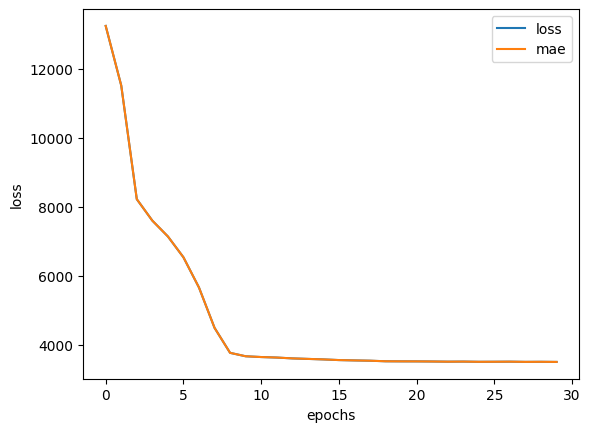

In [ ]:
pd.DataFrame(history.history).plot()
plt.ylabel('loss')
plt.xlabel('epochs')

In [ ]:
#so 100 epochs is enough. bcz after 100. change is almost =  0.